In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import segyio

In [4]:
def load_seismic_data(filepath):
    with segyio.open(filepath, "r", ignore_geometry=True) as f:
        f.mmap()

        # Try to detect geometry
        has_geometry = (
            f.ilines is not None and
            f.xlines is not None and
            f.offsets is not None
        )

        if has_geometry:
            print("✅ Structured 3D detected")
            data = segyio.tools.cube(f)

            # Handle 3D or 4D
            if data.ndim == 4:  # prestack
                data = data[:, :, 0, :]
            elif data.ndim == 3:
                data = data[0, :, :]  # take one inline

        else:
            print("In this data we have no geometry → loading as 2D traces")
            n_traces = f.tracecount
            n_samples = len(f.samples)

            data = np.zeros((n_traces, n_samples), dtype=np.float32)

            for i in range(n_traces):
                data[i, :] = f.trace[i]

        return data.T  # (samples, traces)

filepath = "/home/ashraf/Downloads/ST8511r92.segy"  

seismic = load_seismic_data(filepath)

print("Shape:", seismic.shape)
print("Shape:", seismic.shape)
print("Samples:", seismic.shape[0])
print("Traces:", seismic.shape[1])


In this data we have no geometry → loading as 2D traces
Shape: (227, 112875)
Shape: (227, 112875)
Samples: 227
Traces: 112875


In [5]:
import segyio

with segyio.open("/home/ashraf/Downloads/ST8511r92.segy", "r", ignore_geometry=True) as f:
    print("Traces:", f.tracecount)
    print("Samples per trace:", len(f.samples))
    print("Inline:", f.ilines)
    print("Crossline:", f.xlines)
    print("Offsets:", f.offsets)

Traces: 112875
Samples per trace: 227
Inline: None
Crossline: None
Offsets: None


### Visualisation of seismic data

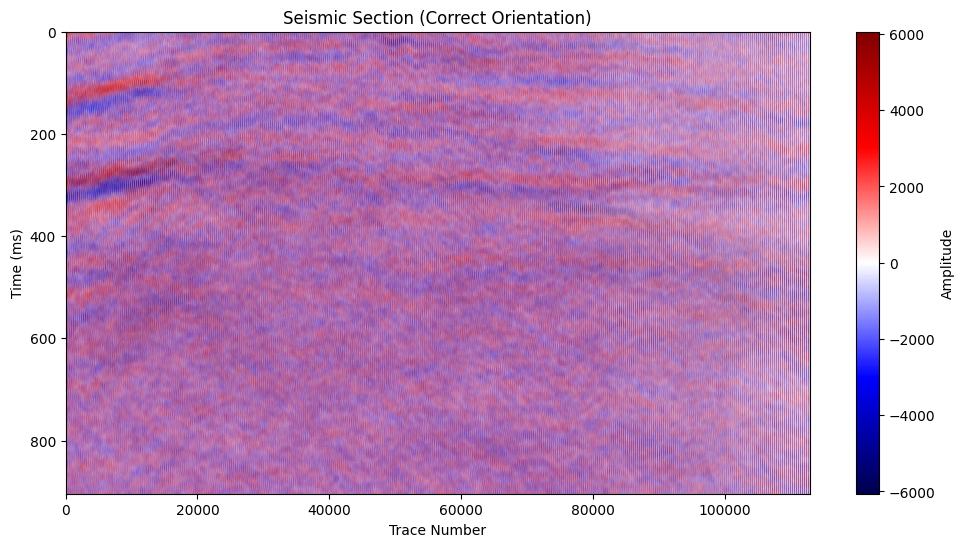

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_seismic(seismic, dt=0.004, clip=98):
    """
    seismic: (samples, traces)
    dt: sampling interval in seconds (default 4 ms)
    """
    
    n_samples, n_traces = seismic.shape
    
    # Time axis (in ms)
    time = np.arange(n_samples) * dt * 1000
    
    # Amplitude clipping (VERY IMPORTANT)
    vmax = np.percentile(np.abs(seismic), clip)
    
    plt.figure(figsize=(12, 6))
    
    plt.imshow(
        seismic,
        cmap='seismic',   # industry standard
        aspect='auto',
        vmin=-vmax,
        vmax=vmax,
        extent=[0, n_traces, time[-1], time[0]]  # correct time axis
    )
    
    plt.xlabel("Trace Number")
    plt.ylabel("Time (ms)")
    plt.title("Seismic Section (Correct Orientation)")
    
    plt.colorbar(label="Amplitude")
    
    plt.show()
plot_seismic(seismic)